# ClusterJudge – Modular Comparison of Clusterings

This notebook implements the specification in `prompt_main.txt`.
Each code cell exposes reusable functions, and each figure is backed by an exported CSV file that can be used to reproduce the plot without rerunning the full pipeline.


## Cell 1 – Setup


In [2]:
# !pip install -q networkx scipy seaborn tqdm

import itertools
import logging
import math
import os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.patches import ConnectionPatch
from scipy.linalg import orthogonal_procrustes
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SETUP_SEED = 42  # Higher changes all random draws in the notebook; lower just selects a different reproducible run.
FIGURE_DIR = "figures/main"  # Change this to redirect all exported figure bundles and CSV payloads.
LOG_PATH = "logs/main.log"  # Change this to keep logs from multiple notebook runs separate.
DEFAULT_DPI = 180  # Higher gives sharper JPGs but larger files; lower writes lighter-weight raster figures.
CLUSTER_MARKERS = ("^", "o", "v", "s", "D", "P", "X")  # Change this to alter marker identity used consistently across clustering plots.
CLUSTER_COLORS = (
    "#4C72B0",
    "#DD8452",
    "#55A868",
    "#C44E52",
    "#8172B3",
    "#937860",
    "#DA8BC3",
)  # Change these to update the consistent cluster palette used across the notebook.


def seed_everything(seed: int) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_parent(path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def save_dataframe(df: pd.DataFrame, path: str | Path) -> Path:
    path = ensure_parent(path)
    df.to_csv(path, index=False)
    return path


def save_figure_bundle(fig, stem: str | Path, dpi: int = DEFAULT_DPI) -> tuple[Path, Path]:
    stem = Path(stem)
    stem.parent.mkdir(parents=True, exist_ok=True)
    jpg_path = stem.with_suffix(".jpg")
    pdf_path = stem.with_suffix(".pdf")
    fig.savefig(jpg_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    return jpg_path, pdf_path


def canonical_pair(i: int, j: int) -> tuple[int, int]:
    i, j = int(i), int(j)
    return (i, j) if i <= j else (j, i)


def cluster_marker(cluster_id: int, markers: tuple[str, ...] = CLUSTER_MARKERS) -> str:
    return markers[int(cluster_id) % len(markers)]


def cluster_color(cluster_id: int, colors: tuple[str, ...] = CLUSTER_COLORS) -> str:
    return colors[int(cluster_id) % len(colors)]


def configure_plot_style() -> None:
    sns.set_theme(style="white", context="paper", font_scale=1.15)
    plt.rcParams["axes.grid"] = False
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"


def finalize_axes(ax, equal_aspect: bool = True) -> None:
    ax.grid(False)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="box")
    sns.despine(ax=ax)


def progress_iter(iterable, enabled: bool, **kwargs):
    return tqdm(iterable, **kwargs) if enabled else iterable


def plot_cluster_assignments_from_csv(
    csv_path: str | Path,
    stem: str | Path,
    title: str,
    cluster_col: str = "inferred_cluster",
    markers: tuple[str, ...] = CLUSTER_MARKERS,
    colors: tuple[str, ...] = CLUSTER_COLORS,
    equal_aspect: bool = True,
) -> tuple[Path, Path]:
    df = pd.read_csv(csv_path)
    if "entity_type" in df.columns:
        point_df = df[df["entity_type"] == "point"].copy()
        edge_df = df[df["entity_type"] == "edge"].copy()
    else:
        point_df = df.copy()
        edge_df = pd.DataFrame(columns=["x", "y", "x_end", "y_end", "color", "line_style", "alpha", "linewidth"])

    fig, ax = plt.subplots(figsize=(5.8, 4.8))

    for row in edge_df.itertuples(index=False):
        ax.plot(
            [row.x, row.x_end],
            [row.y, row.y_end],
            color=row.color,
            linestyle=row.line_style,
            linewidth=float(row.linewidth),
            alpha=float(row.alpha),
            zorder=1,
        )

    for cluster_id in sorted(point_df[cluster_col].unique()):
        mask = point_df[cluster_col] == cluster_id
        ax.scatter(
            point_df.loc[mask, "x"],
            point_df.loc[mask, "y"],
            facecolors="none",
            edgecolors=cluster_color(int(cluster_id), colors),
            marker=cluster_marker(int(cluster_id), markers),
            linewidths=1.8,
            s=92,
            label=f"Cluster {int(cluster_id)}",
            zorder=2,
        )

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(frameon=False, fontsize=8)
    finalize_axes(ax, equal_aspect=equal_aspect)
    fig.tight_layout()
    paths = save_figure_bundle(fig, stem)
    plt.show()
    plt.close(fig)
    return paths


def pairwise_consistency_metrics(true_labels, pred_labels) -> dict:
    true_labels = np.asarray(true_labels)
    pred_labels = np.asarray(pred_labels)
    tp = tn = fp = fn = 0
    for i in range(len(true_labels)):
        for j in range(i + 1, len(true_labels)):
            true_same = int(true_labels[i] == true_labels[j])
            pred_same = int(pred_labels[i] == pred_labels[j])
            if true_same == 1 and pred_same == 1:
                tp += 1
            elif true_same == 0 and pred_same == 0:
                tn += 1
            elif true_same == 0 and pred_same == 1:
                fp += 1
            else:
                fn += 1

    total = tp + tn + fp + fn
    pos_total = tp + fn
    neg_total = tn + fp
    tpr = tp / pos_total if pos_total else 0.0
    tnr = tn / neg_total if neg_total else 0.0
    return {
        "pair_accuracy": (tp + tn) / total if total else 0.0,
        "balanced_accuracy": 0.5 * (tpr + tnr),
        "true_positive_rate": tpr,
        "true_negative_rate": tnr,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


def assignment_dict_to_array(assignment: dict[int, int], n_points: int) -> np.ndarray:
    return np.array([int(assignment.get(i, 0)) for i in range(n_points)], dtype=int)


def build_edge_overlay_rows(
    points_df: pd.DataFrame,
    edge_pairs: list[tuple[int, int]],
    color: str,
    line_style: str,
    alpha: float,
    linewidth: float,
) -> list[dict]:
    coords = points_df.set_index("point_idx")[["x", "y"]]
    rows = []
    for i, j in edge_pairs:
        rows.append(
            {
                "entity_type": "edge",
                "point_idx": -1,
                "x": float(coords.loc[int(i), "x"]),
                "y": float(coords.loc[int(i), "y"]),
                "x_end": float(coords.loc[int(j), "x"]),
                "y_end": float(coords.loc[int(j), "y"]),
                "true_cluster": -1,
                "inferred_cluster": -1,
                "color": color,
                "line_style": line_style,
                "alpha": alpha,
                "linewidth": linewidth,
            }
        )
    return rows


def run_kmeans(
    x: np.ndarray,
    n_clusters: int,
    n_init: int,
    max_iter: int,
    seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    best_labels = None
    best_inertia = np.inf
    n_points = x.shape[0]
    for init_idx in range(n_init):
        center_idx = rng.choice(n_points, size=n_clusters, replace=False)
        centers = x[center_idx].copy()
        labels = np.zeros(n_points, dtype=int)
        for _ in range(max_iter):
            distances = np.linalg.norm(x[:, None, :] - centers[None, :, :], axis=-1)
            new_labels = distances.argmin(axis=1)
            new_centers = centers.copy()
            for cluster_id in range(n_clusters):
                mask = new_labels == cluster_id
                if np.any(mask):
                    new_centers[cluster_id] = x[mask].mean(axis=0)
                else:
                    new_centers[cluster_id] = x[int(rng.integers(0, n_points))]
            if np.array_equal(new_labels, labels):
                labels = new_labels
                centers = new_centers
                break
            labels = new_labels
            centers = new_centers
        inertia = float(np.sum((x - centers[labels]) ** 2))
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
    return np.asarray(best_labels, dtype=int)


seed_everything(SETUP_SEED)
configure_plot_style()
Path(FIGURE_DIR).mkdir(parents=True, exist_ok=True)
Path(LOG_PATH).parent.mkdir(parents=True, exist_ok=True)
logging.basicConfig(
    filename=LOG_PATH,
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    force=True,
)

MAIN_ENV = {
    "seed": SETUP_SEED,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float32,
    "figure_dir": FIGURE_DIR,
    "log_path": LOG_PATH,
}
MAIN_STATE = {}

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {MAIN_ENV['device']}")
print(f"Figure dir      : {MAIN_ENV['figure_dir']}")
print(f"Log path        : {MAIN_ENV['log_path']}")


PyTorch version : 2.11.0
Device          : cpu
Figure dir      : figures/main
Log path        : logs/main.log


## Cell 2 – Dataset Generation


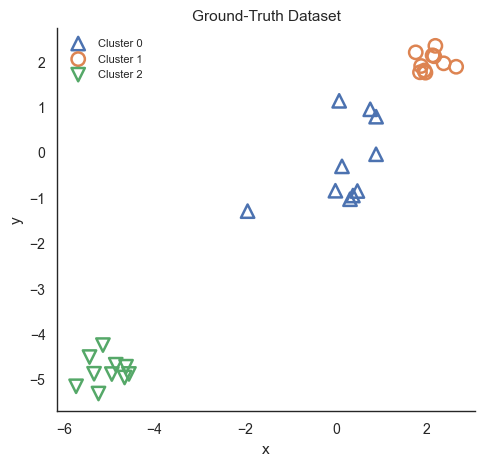

,point_idx,x,y,true_cluster
0,0,0.304717,-1.039984,0
1,1,0.750451,0.940565,0
2,2,-1.951035,-1.302180,0
3,3,0.127840,-0.316243,0
4,4,-0.016801,-0.853044,0


In [3]:
DATASET_POINTS_PER_CLUSTER = 10  # Higher creates denser clouds per cluster; lower makes the sample geometry visibly rougher.
DATASET_SEED = 42  # Higher changes the sampled coordinates but keeps the experiment reproducible.
DATASET_CLUSTER_PARAMS = [
    {"mean_x": 0.0, "mean_y": 0.0, "std": 1.0, "label": 0},
    {"mean_x": 2.0, "mean_y": 0.0, "std": 0.3, "label": 1},
    {"mean_x": -5.0, "mean_y": -5.0, "std": 0.5, "label": 2},
]  # Increasing std or moving means closer makes the clusters overlap more; decreasing std or spreading means apart makes them easier.
DATASET_CSV_PATH = f"{MAIN_ENV['figure_dir']}/ground_truth.csv"  # Change this to save the dataset payload to a different location.
DATASET_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/ground_truth"  # Change this stem to rename the JPG/PDF figure bundle.


def generate_gaussian_dataset(cluster_params: list[dict], points_per_cluster: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    point_idx = 0
    for spec in cluster_params:
        mean = np.array([spec["mean_x"], spec["mean_y"]], dtype=float)
        samples = rng.normal(loc=mean, scale=float(spec["std"]), size=(points_per_cluster, 2))
        for x_coord, y_coord in samples:
            rows.append(
                {
                    "point_idx": point_idx,
                    "x": float(x_coord),
                    "y": float(y_coord),
                    "true_cluster": int(spec["label"]),
                }
            )
            point_idx += 1
    return pd.DataFrame(rows)


def plot_ground_truth_from_csv(
    csv_path: str | Path,
    stem: str | Path,
    markers: tuple[str, ...] = CLUSTER_MARKERS,
    colors: tuple[str, ...] = CLUSTER_COLORS,
) -> tuple[Path, Path]:
    df = pd.read_csv(csv_path)
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    for cluster_id in sorted(df["true_cluster"].unique()):
        mask = df["true_cluster"] == cluster_id
        ax.scatter(
            df.loc[mask, "x"],
            df.loc[mask, "y"],
            facecolors="none",
            edgecolors=cluster_color(int(cluster_id), colors),
            marker=cluster_marker(int(cluster_id), markers),
            linewidths=1.8,
            s=92,
            label=f"Cluster {int(cluster_id)}",
        )
    ax.set_title("Ground-Truth Dataset")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(frameon=False, fontsize=8)
    finalize_axes(ax, equal_aspect=True)
    fig.tight_layout()
    paths = save_figure_bundle(fig, stem)
    plt.show()
    plt.close(fig)
    return paths


def run_dataset_cell(
    cluster_params: list[dict],
    points_per_cluster: int,
    seed: int,
    csv_path: str | Path,
    figure_stem: str | Path,
) -> dict:
    points_df = generate_gaussian_dataset(cluster_params, points_per_cluster, seed)
    save_dataframe(points_df, csv_path)
    plot_ground_truth_from_csv(csv_path, figure_stem)
    logging.info("Dataset cell complete with %d points", len(points_df))
    return {
        "points_df": points_df,
        "csv_path": str(csv_path),
        "figure_stem": str(figure_stem),
    }


MAIN_STATE["dataset"] = run_dataset_cell(
    cluster_params=DATASET_CLUSTER_PARAMS,
    points_per_cluster=DATASET_POINTS_PER_CLUSTER,
    seed=DATASET_SEED,
    csv_path=DATASET_CSV_PATH,
    figure_stem=DATASET_FIGURE_STEM,
)

MAIN_STATE["dataset"]["points_df"].head()


## Cell 3 – Judgement Generation


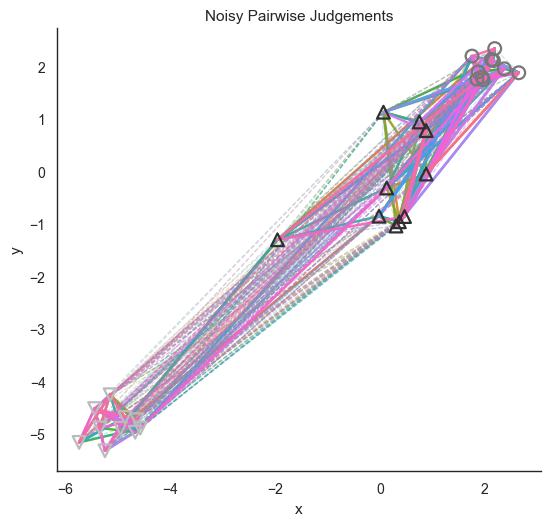

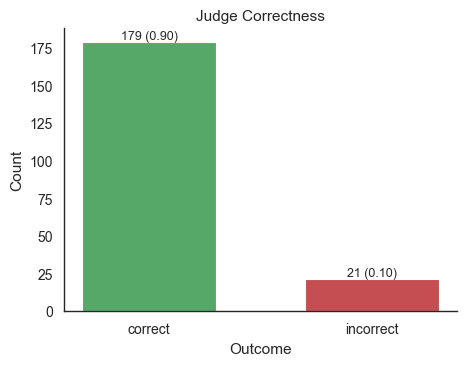

,judgement_id,a_idx,b_idx,c_idx,winner_i,winner_j,loser1_i,loser1_j,loser2_i,loser2_j,shortest_i,shortest_j,distance_ab,distance_ac,distance_bc,winner_prob,winner_is_correct
0,0,19,2,22,2,22,2,19,19,22,2,22,5.094000,9.747967,4.671293,0.601862,1
1,1,24,2,5,2,5,2,24,5,24,2,5,4.557034,7.980258,3.512497,0.733499,1
2,2,15,22,20,20,22,15,22,15,20,20,22,10.165386,9.824018,0.352798,0.999868,1
3,3,12,5,27,5,12,12,27,5,27,5,12,1.493651,10.126397,8.635066,0.999031,1
4,4,12,13,15,12,13,12,15,13,15,12,13,0.359718,0.771165,0.535459,0.399756,1


In [21]:
JUDGEMENT_COUNT = 200  # Higher covers more triplets and strengthens the graph signal; lower keeps the observations sparse.
JUDGEMENT_TEMPERATURE = 1.0  # Higher makes the judge noisier; lower makes the nearest pair win more deterministically.
JUDGEMENT_SEED = 42  # Higher changes which triplets are sampled and how the noisy choices resolve.
JUDGEMENT_PLOT_LIMIT = 5  # Higher shows more query edges in the visualization; lower keeps the figure cleaner.
JUDGEMENTS_CSV_PATH = f"{MAIN_ENV['figure_dir']}/judgements.csv"  # Change this to write the one-row-per-judgement payload elsewhere.
JUDGEMENT_PLOT_CSV_PATH = f"{MAIN_ENV['figure_dir']}/judgements_plot.csv"  # Change this to archive the plotting payload separately.
JUDGEMENT_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/judgements"  # Change this stem to rename the judgement figure bundle.
JUDGE_ACCURACY_CSV_PATH = f"{MAIN_ENV['figure_dir']}/judge_accuracy.csv"  # Change this to keep multiple correctness summaries.
JUDGE_ACCURACY_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/judge_accuracy"  # Change this stem to rename the correctness figure bundle.


def generate_triplet_judgements(
    points_df: pd.DataFrame,
    n_judgements: int,
    temperature: float,
    seed: int,
    show_progress: bool = False,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    coords = points_df[["x", "y"]].to_numpy(dtype=float)
    rows = []
    iterator = progress_iter(range(n_judgements), enabled=show_progress, desc="Judgements", leave=False)
    for judgement_id in iterator:
        a_idx, b_idx, c_idx = rng.choice(len(points_df), size=3, replace=False)
        candidate_pairs = [
            canonical_pair(a_idx, b_idx),
            canonical_pair(a_idx, c_idx),
            canonical_pair(b_idx, c_idx),
        ]
        distances = np.array(
            [np.linalg.norm(coords[i] - coords[j]) for i, j in candidate_pairs],
            dtype=float,
        )
        weights = np.exp(-distances / max(float(temperature), 1e-6))
        probs = weights / weights.sum()
        winner_pos = int(rng.choice(len(candidate_pairs), p=probs))
        winner_pair = candidate_pairs[winner_pos]
        loser_pairs = [pair for pos, pair in enumerate(candidate_pairs) if pos != winner_pos]
        shortest_pos = int(np.argmin(distances))
        shortest_pair = candidate_pairs[shortest_pos]
        rows.append(
            {
                "judgement_id": judgement_id,
                "a_idx": int(a_idx),
                "b_idx": int(b_idx),
                "c_idx": int(c_idx),
                "winner_i": int(winner_pair[0]),
                "winner_j": int(winner_pair[1]),
                "loser1_i": int(loser_pairs[0][0]),
                "loser1_j": int(loser_pairs[0][1]),
                "loser2_i": int(loser_pairs[1][0]),
                "loser2_j": int(loser_pairs[1][1]),
                "shortest_i": int(shortest_pair[0]),
                "shortest_j": int(shortest_pair[1]),
                "distance_ab": float(distances[0]),
                "distance_ac": float(distances[1]),
                "distance_bc": float(distances[2]),
                "winner_prob": float(probs[winner_pos]),
                "winner_is_correct": int(winner_pair == shortest_pair),
            }
        )
    return pd.DataFrame(rows)


def build_judgement_plot_dataframe(
    points_df: pd.DataFrame,
    judgements_df: pd.DataFrame,
    plot_limit: int,
) -> pd.DataFrame:
    gray_shades = ("#2F2F2F", "#777777", "#BBBBBB")
    visible_df = judgements_df.head(plot_limit).copy()
    palette = sns.color_palette("husl", max(len(visible_df), 3))
    rows = []

    for row in points_df.itertuples(index=False):
        rows.append(
            {
                "entity_type": "point",
                "judgement_id": -1,
                "x": float(row.x),
                "y": float(row.y),
                "x_end": np.nan,
                "y_end": np.nan,
                "cluster_id": int(row.true_cluster),
                "color": gray_shades[int(row.true_cluster) % len(gray_shades)],
                "marker": cluster_marker(int(row.true_cluster)),
                "line_style": "",
                "alpha": 1.0,
                "linewidth": 1.4,
            }
        )

    coord_lookup = points_df.set_index("point_idx")[["x", "y"]]
    for local_idx, row in enumerate(visible_df.itertuples(index=False)):
        color = palette[local_idx % len(palette)]
        color_hex = "#{:02x}{:02x}{:02x}".format(
            int(color[0] * 255), int(color[1] * 255), int(color[2] * 255)
        )
        line_specs = [
            ((int(row.winner_i), int(row.winner_j)), "-", 0.95, 1.8),
            ((int(row.loser1_i), int(row.loser1_j)), "--", 0.28, 0.9),
            ((int(row.loser2_i), int(row.loser2_j)), "--", 0.28, 0.9),
        ]
        for pair, line_style, alpha, linewidth in line_specs:
            rows.append(
                {
                    "entity_type": "edge",
                    "judgement_id": int(row.judgement_id),
                    "x": float(coord_lookup.loc[pair[0], "x"]),
                    "y": float(coord_lookup.loc[pair[0], "y"]),
                    "x_end": float(coord_lookup.loc[pair[1], "x"]),
                    "y_end": float(coord_lookup.loc[pair[1], "y"]),
                    "cluster_id": -1,
                    "color": color_hex,
                    "marker": "",
                    "line_style": line_style,
                    "alpha": alpha,
                    "linewidth": linewidth,
                }
            )
    return pd.DataFrame(rows)


def plot_judgements_from_csv(csv_path: str | Path, stem: str | Path) -> tuple[Path, Path]:
    df = pd.read_csv(csv_path)
    point_df = df[df["entity_type"] == "point"].copy()
    edge_df = df[df["entity_type"] == "edge"].copy()
    fig, ax = plt.subplots(figsize=(6.4, 5.4))
    for row in edge_df.itertuples(index=False):
        ax.plot(
            [row.x, row.x_end],
            [row.y, row.y_end],
            color=row.color,
            linestyle=row.line_style,
            linewidth=float(row.linewidth),
            alpha=float(row.alpha),
            zorder=1,
        )
    for row in point_df.itertuples(index=False):
        ax.scatter(
            row.x,
            row.y,
            facecolors="none",
            edgecolors=row.color,
            marker=row.marker,
            linewidths=1.6,
            s=84,
            zorder=2,
        )
    ax.set_title("Noisy Pairwise Judgements (first 5 shown)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    finalize_axes(ax, equal_aspect=True)
    fig.tight_layout()
    paths = save_figure_bundle(fig, stem)
    plt.show()
    plt.close(fig)
    return paths


def build_judge_accuracy_dataframe(judgements_df: pd.DataFrame) -> pd.DataFrame:
    correct_count = int(judgements_df["winner_is_correct"].sum())
    incorrect_count = int(len(judgements_df) - correct_count)
    return pd.DataFrame(
        {
            "outcome": ["correct", "incorrect"],
            "count": [correct_count, incorrect_count],
            "fraction": [correct_count / max(len(judgements_df), 1), incorrect_count / max(len(judgements_df), 1)],
        }
    )


def plot_judge_accuracy_from_csv(csv_path: str | Path, stem: str | Path) -> tuple[Path, Path]:
    df = pd.read_csv(csv_path)
    fig, ax = plt.subplots(figsize=(4.8, 3.8))
    bar_colors = ["#55A868", "#C44E52"]
    ax.bar(df["outcome"], df["count"], color=bar_colors, width=0.6)
    for row in df.itertuples(index=False):
        ax.text(row.outcome, row.count, f"{row.count} ({row.fraction:.2f})", ha="center", va="bottom", fontsize=9)
    ax.set_title("Judge Correctness")
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Count")
    finalize_axes(ax, equal_aspect=False)
    fig.tight_layout()
    paths = save_figure_bundle(fig, stem)
    plt.show()
    plt.close(fig)
    return paths


def run_judgement_cell(
    points_csv_path: str | Path,
    n_judgements: int,
    temperature: float,
    seed: int,
    plot_limit: int,
    judgements_csv_path: str | Path,
    plot_csv_path: str | Path,
    figure_stem: str | Path,
    accuracy_csv_path: str | Path,
    accuracy_figure_stem: str | Path,
) -> dict:
    points_df = pd.read_csv(points_csv_path)
    judgements_df = generate_triplet_judgements(points_df, n_judgements, temperature, seed, show_progress=False)
    save_dataframe(judgements_df, judgements_csv_path)
    plot_df = build_judgement_plot_dataframe(points_df, judgements_df, plot_limit)
    save_dataframe(plot_df, plot_csv_path)
    plot_judgements_from_csv(plot_csv_path, figure_stem)
    accuracy_df = build_judge_accuracy_dataframe(judgements_df)
    save_dataframe(accuracy_df, accuracy_csv_path)
    plot_judge_accuracy_from_csv(accuracy_csv_path, accuracy_figure_stem)
    logging.info("Judgement cell complete with %.2f correct fraction", accuracy_df.loc[0, "fraction"])
    return {
        "judgements_df": judgements_df,
        "judgements_csv_path": str(judgements_csv_path),
        "plot_csv_path": str(plot_csv_path),
        "accuracy_csv_path": str(accuracy_csv_path),
    }


MAIN_STATE["judgements"] = run_judgement_cell(
    points_csv_path=MAIN_STATE["dataset"]["csv_path"],
    n_judgements=JUDGEMENT_COUNT,
    temperature=JUDGEMENT_TEMPERATURE,
    seed=JUDGEMENT_SEED,
    plot_limit=JUDGEMENT_PLOT_LIMIT,
    judgements_csv_path=JUDGEMENTS_CSV_PATH,
    plot_csv_path=JUDGEMENT_PLOT_CSV_PATH,
    figure_stem=JUDGEMENT_FIGURE_STEM,
    accuracy_csv_path=JUDGE_ACCURACY_CSV_PATH,
    accuracy_figure_stem=JUDGE_ACCURACY_FIGURE_STEM,
)

MAIN_STATE["judgements"]["judgements_df"].head()


## Cell 4 – Cluster Generation (Max Cut)


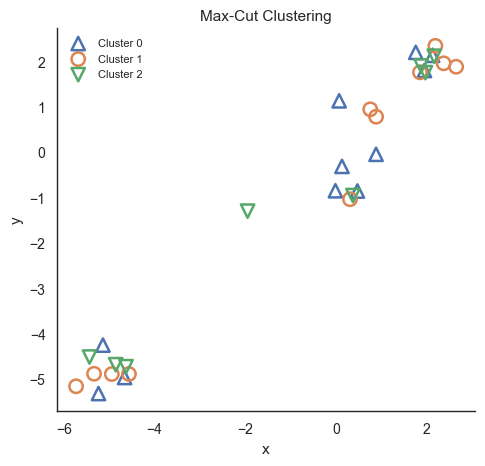

{'pair_accuracy': 0.5471264367816092,
 'balanced_accuracy': 0.4740740740740741,
 'true_positive_rate': 0.2814814814814815,
 'true_negative_rate': 0.6666666666666666,
 'tp': 38,
 'tn': 200,
 'fp': 100,
 'fn': 97}

In [22]:
MAXCUT_CLUSTER_COUNT = 3  # Higher asks the partitioner for finer splits; lower merges the graph more coarsely.
MAXCUT_RESTARTS = 40  # Higher explores more random initial assignments; lower is faster but less stable.
MAXCUT_MAX_ITER = 250  # Higher lets local search settle more fully; lower stops sooner with rougher cuts.
MAXCUT_SIZE_REGULARIZATION = 0.45  # Higher pushes cluster sizes closer together; lower lets the cut objective dominate more strongly.
MAXCUT_CSV_PATH = f"{MAIN_ENV['figure_dir']}/maxcut_clusters.csv"  # Change this to keep several max-cut outputs.
MAXCUT_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/maxcut_clusters"  # Change this stem to rename the saved max-cut figures.


def build_dashed_graph_from_judgements(judgements_df: pd.DataFrame, n_points: int) -> nx.Graph:
    graph = nx.Graph()
    graph.add_nodes_from(range(n_points))
    for row in judgements_df.itertuples(index=False):
        for pair in [
            canonical_pair(row.loser1_i, row.loser1_j),
            canonical_pair(row.loser2_i, row.loser2_j),
        ]:
            if graph.has_edge(*pair):
                graph[pair[0]][pair[1]]["weight"] += 1.0
            else:
                graph.add_edge(pair[0], pair[1], weight=1.0)
    return graph


def infer_maxcut_labels_from_judgements(
    judgements_df: pd.DataFrame,
    n_points: int,
    n_clusters: int,
    n_restarts: int,
    max_iter: int,
    size_regularization: float,
    seed: int,
) -> tuple[np.ndarray, nx.Graph]:
    graph = build_dashed_graph_from_judgements(judgements_df, n_points)
    nodes = list(graph.nodes())
    target_size = max(len(nodes) / max(n_clusters, 1), 1.0)
    rng = np.random.default_rng(seed)

    def objective(assignment: dict[int, int]) -> float:
        cut_value = 0.0
        for u, v, edge_data in graph.edges(data=True):
            if assignment[u] != assignment[v]:
                cut_value += float(edge_data.get("weight", 1.0))
        counts = np.bincount([assignment[node] for node in nodes], minlength=n_clusters).astype(float)
        penalty = np.mean((counts - target_size) ** 2) / target_size
        return float(cut_value - size_regularization * penalty)

    best_assignment = {node: 0 for node in nodes}
    best_value = -np.inf
    for _ in range(n_restarts):
        assignment = {node: int(rng.integers(0, n_clusters)) for node in nodes}
        current_value = objective(assignment)
        for _ in range(max_iter):
            improved = False
            order = list(nodes)
            rng.shuffle(order)
            for node in order:
                current_cluster = assignment[node]
                local_best_cluster = current_cluster
                local_best_value = current_value
                for candidate_cluster in range(n_clusters):
                    if candidate_cluster == current_cluster:
                        continue
                    assignment[node] = candidate_cluster
                    candidate_value = objective(assignment)
                    if candidate_value > local_best_value:
                        local_best_cluster = candidate_cluster
                        local_best_value = candidate_value
                    assignment[node] = current_cluster
                if local_best_cluster != current_cluster:
                    assignment[node] = local_best_cluster
                    current_value = local_best_value
                    improved = True
            if not improved:
                break
        final_value = objective(assignment)
        if final_value > best_value:
            best_value = final_value
            best_assignment = dict(assignment)

    return assignment_dict_to_array(best_assignment, n_points), graph


def run_maxcut_cell(
    points_csv_path: str | Path,
    judgements_csv_path: str | Path,
    n_clusters: int,
    n_restarts: int,
    max_iter: int,
    size_regularization: float,
    seed: int,
    csv_path: str | Path,
    figure_stem: str | Path,
) -> dict:
    points_df = pd.read_csv(points_csv_path)
    judgements_df = pd.read_csv(judgements_csv_path)
    inferred, graph = infer_maxcut_labels_from_judgements(
        judgements_df=judgements_df,
        n_points=len(points_df),
        n_clusters=n_clusters,
        n_restarts=n_restarts,
        max_iter=max_iter,
        size_regularization=size_regularization,
        seed=seed,
    )
    point_rows = points_df.copy()
    point_rows["entity_type"] = "point"
    point_rows["x_end"] = np.nan
    point_rows["y_end"] = np.nan
    point_rows["color"] = ""
    point_rows["line_style"] = ""
    point_rows["alpha"] = np.nan
    point_rows["linewidth"] = np.nan
    point_rows["inferred_cluster"] = inferred
    edge_rows = pd.DataFrame(
        build_edge_overlay_rows(
            points_df=points_df,
            edge_pairs=[canonical_pair(u, v) for u, v in graph.edges()],
            color="#7F7F7F",
            line_style="--",
            alpha=0.30,
            linewidth=0.9,
        )
    )
    export_df = pd.concat([point_rows, edge_rows], ignore_index=True, sort=False)
    save_dataframe(export_df, csv_path)
    plot_cluster_assignments_from_csv(csv_path, figure_stem, "Max-Cut Clustering (from dashed edges)")
    metrics = pairwise_consistency_metrics(points_df["true_cluster"], inferred)
    logging.info("Max-cut metrics: %s", metrics)
    return {"clusters_df": export_df, "csv_path": str(csv_path), "metrics": metrics}


MAIN_STATE["maxcut"] = run_maxcut_cell(
    points_csv_path=MAIN_STATE["dataset"]["csv_path"],
    judgements_csv_path=MAIN_STATE["judgements"]["judgements_csv_path"],
    n_clusters=MAXCUT_CLUSTER_COUNT,
    n_restarts=MAXCUT_RESTARTS,
    max_iter=MAXCUT_MAX_ITER,
    size_regularization=MAXCUT_SIZE_REGULARIZATION,
    seed=SETUP_SEED,
    csv_path=MAXCUT_CSV_PATH,
    figure_stem=MAXCUT_FIGURE_STEM,
)

MAIN_STATE["maxcut"]["metrics"]


## Cell 5 – Cluster Generation II (Min Cut)


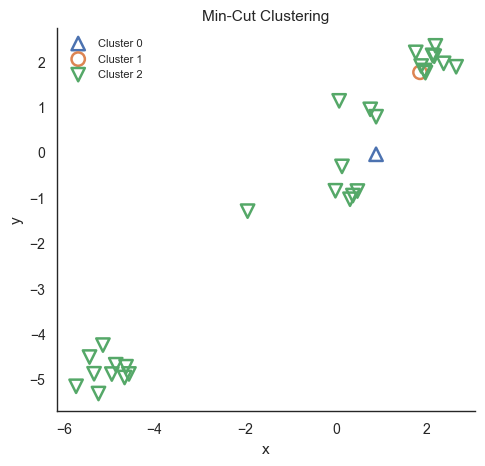

{'pair_accuracy': 0.3586206896551724,
 'balanced_accuracy': 0.49833333333333335,
 'true_positive_rate': 0.8666666666666667,
 'true_negative_rate': 0.13,
 'tp': 117,
 'tn': 39,
 'fp': 261,
 'fn': 18}

In [23]:
MINCUT_CLUSTER_COUNT = 3  # Higher forces more splits from winner edges; lower gives broader clusters.
MINCUT_CSV_PATH = f"{MAIN_ENV['figure_dir']}/mincut_clusters.csv"  # Change this to archive alternative min-cut outputs.
MINCUT_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/mincut_clusters"  # Change this stem to rename the min-cut figure bundle.


def build_solid_graph_from_judgements(judgements_df: pd.DataFrame, n_points: int) -> nx.Graph:
    graph = nx.Graph()
    graph.add_nodes_from(range(n_points))
    for row in judgements_df.itertuples(index=False):
        pair = canonical_pair(row.winner_i, row.winner_j)
        if graph.has_edge(*pair):
            graph[pair[0]][pair[1]]["weight"] += 1.0
        else:
            graph.add_edge(pair[0], pair[1], weight=1.0)
    return graph


def infer_mincut_labels_from_judgements(
    judgements_df: pd.DataFrame,
    n_points: int,
    n_clusters: int,
) -> tuple[np.ndarray, nx.Graph]:
    graph = build_solid_graph_from_judgements(judgements_df, n_points)
    assignment = hierarchical_mincut_partition(graph, n_clusters)
    return assignment_dict_to_array(assignment, n_points), graph


def run_mincut_cell(
    points_csv_path: str | Path,
    judgements_csv_path: str | Path,
    n_clusters: int,
    csv_path: str | Path,
    figure_stem: str | Path,
) -> dict:
    points_df = pd.read_csv(points_csv_path)
    judgements_df = pd.read_csv(judgements_csv_path)
    inferred, graph = infer_mincut_labels_from_judgements(judgements_df, len(points_df), n_clusters)
    point_rows = points_df.copy()
    point_rows["entity_type"] = "point"
    point_rows["x_end"] = np.nan
    point_rows["y_end"] = np.nan
    point_rows["color"] = ""
    point_rows["line_style"] = ""
    point_rows["alpha"] = np.nan
    point_rows["linewidth"] = np.nan
    point_rows["inferred_cluster"] = inferred
    edge_rows = pd.DataFrame(
        build_edge_overlay_rows(
            points_df=points_df,
            edge_pairs=[canonical_pair(u, v) for u, v in graph.edges()],
            color="#7F7F7F",
            line_style="-",
            alpha=0.30,
            linewidth=0.9,
        )
    )
    export_df = pd.concat([point_rows, edge_rows], ignore_index=True, sort=False)
    save_dataframe(export_df, csv_path)
    plot_cluster_assignments_from_csv(csv_path, figure_stem, "Min-Cut Clustering (from solid edges)")
    metrics = pairwise_consistency_metrics(points_df["true_cluster"], inferred)
    logging.info("Min-cut metrics: %s", metrics)
    return {"clusters_df": export_df, "csv_path": str(csv_path), "metrics": metrics}


MAIN_STATE["mincut"] = run_mincut_cell(
    points_csv_path=MAIN_STATE["dataset"]["csv_path"],
    judgements_csv_path=MAIN_STATE["judgements"]["judgements_csv_path"],
    n_clusters=MINCUT_CLUSTER_COUNT,
    csv_path=MINCUT_CSV_PATH,
    figure_stem=MINCUT_FIGURE_STEM,
)

MAIN_STATE["mincut"]["metrics"]


## Cell 6 – Meta Graph


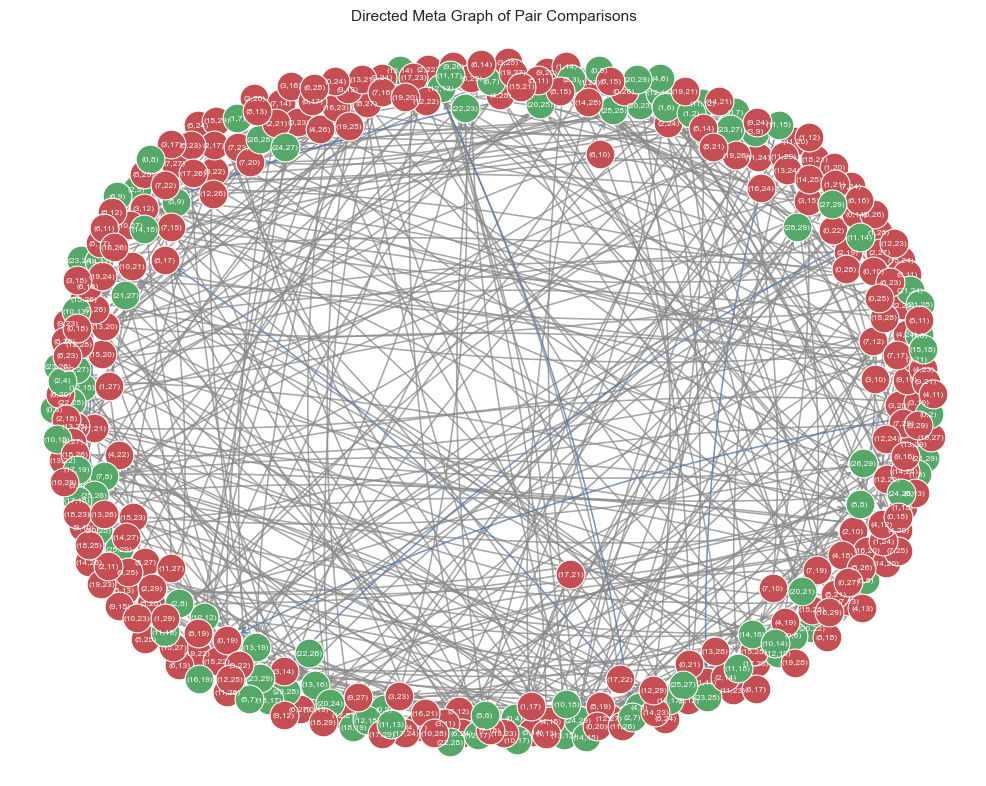

(324, 396)

In [24]:
META_GRAPH_LAYOUT_SEED = 42  # Higher changes only the layout of the graph drawing; the graph structure stays the same.
META_GRAPH_CSV_PATH = f"{MAIN_ENV['figure_dir']}/meta_graph.csv"  # Change this to keep different rendered layouts.
META_GRAPH_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/meta_graph"  # Change this stem to rename the meta-graph figure bundle.


def build_meta_graph(judgements_df: pd.DataFrame, true_labels: np.ndarray) -> nx.DiGraph:
    graph = nx.DiGraph()
    for row in judgements_df.itertuples(index=False):
        winner = canonical_pair(row.winner_i, row.winner_j)
        loser_pairs = [
            canonical_pair(row.loser1_i, row.loser1_j),
            canonical_pair(row.loser2_i, row.loser2_j),
        ]
        for pair in [winner] + loser_pairs:
            if pair not in graph:
                graph.add_node(pair, same_cluster=int(true_labels[pair[0]] == true_labels[pair[1]]))
        for loser in loser_pairs:
            graph.add_edge(loser, winner)
    return graph


def export_meta_graph_csv(graph: nx.DiGraph, seed: int, csv_path: str | Path) -> Path:
    positions = nx.spring_layout(graph, seed=seed, k=1.8)
    rows = []
    for node, (x_coord, y_coord) in positions.items():
        rows.append(
            {
                "entity_type": "node",
                "source_i": int(node[0]),
                "source_j": int(node[1]),
                "target_i": -1,
                "target_j": -1,
                "x": float(x_coord),
                "y": float(y_coord),
                "x_end": np.nan,
                "y_end": np.nan,
                "same_cluster": int(graph.nodes[node]["same_cluster"]),
            }
        )
    for source, target in graph.edges():
        rows.append(
            {
                "entity_type": "edge",
                "source_i": int(source[0]),
                "source_j": int(source[1]),
                "target_i": int(target[0]),
                "target_j": int(target[1]),
                "x": float(positions[source][0]),
                "y": float(positions[source][1]),
                "x_end": float(positions[target][0]),
                "y_end": float(positions[target][1]),
                "same_cluster": int(graph.nodes[source]["same_cluster"]),
            }
        )
    save_dataframe(pd.DataFrame(rows), csv_path)
    return Path(csv_path)


def plot_meta_graph_from_csv(csv_path: str | Path, stem: str | Path) -> tuple[Path, Path]:
    df = pd.read_csv(csv_path)
    node_df = df[df["entity_type"] == "node"].copy()
    edge_df = df[df["entity_type"] == "edge"].copy()
    same_lookup = {
        (int(row.source_i), int(row.source_j)): int(row.same_cluster)
        for row in node_df.itertuples(index=False)
    }
    fig, ax = plt.subplots(figsize=(10.0, 8.0))
    for row in edge_df.itertuples(index=False):
        source_same = same_lookup[(int(row.source_i), int(row.source_j))]
        target_same = same_lookup[(int(row.target_i), int(row.target_j))]
        color = "#4C72B0" if source_same == 1 and target_same == 0 else "#8A8A8A"
        ax.annotate(
            "",
            xy=(row.x_end, row.y_end),
            xytext=(row.x, row.y),
            arrowprops=dict(
                arrowstyle="->",
                color=color,
                lw=1.15,
                alpha=0.75,
                shrinkA=10,
                shrinkB=10,
                connectionstyle="arc3,rad=0.08",
            ),
        )
    for row in node_df.itertuples(index=False):
        color = "#55A868" if int(row.same_cluster) == 1 else "#C44E52"
        ax.scatter(row.x, row.y, s=430, color=color, edgecolors="white", linewidths=0.8, zorder=3)
        ax.text(row.x, row.y, f"({int(row.source_i)},{int(row.source_j)})", ha="center", va="center", fontsize=6, color="white", zorder=4)
    ax.set_title("Directed Meta Graph of Pair Comparisons")
    ax.axis("off")
    fig.tight_layout()
    paths = save_figure_bundle(fig, stem)
    plt.show()
    plt.close(fig)
    return paths


def run_meta_graph_cell(
    points_csv_path: str | Path,
    judgements_csv_path: str | Path,
    layout_seed: int,
    csv_path: str | Path,
    figure_stem: str | Path,
) -> dict:
    points_df = pd.read_csv(points_csv_path)
    judgements_df = pd.read_csv(judgements_csv_path)
    graph = build_meta_graph(judgements_df, points_df["true_cluster"].to_numpy(dtype=int))
    export_meta_graph_csv(graph, layout_seed, csv_path)
    plot_meta_graph_from_csv(csv_path, figure_stem)
    logging.info("Meta graph cell complete with %d nodes", graph.number_of_nodes())
    return {"graph": graph, "csv_path": str(csv_path)}


MAIN_STATE["meta_graph"] = run_meta_graph_cell(
    points_csv_path=MAIN_STATE["dataset"]["csv_path"],
    judgements_csv_path=MAIN_STATE["judgements"]["judgements_csv_path"],
    layout_seed=META_GRAPH_LAYOUT_SEED,
    csv_path=META_GRAPH_CSV_PATH,
    figure_stem=META_GRAPH_FIGURE_STEM,
)

(
    MAIN_STATE["meta_graph"]["graph"].number_of_nodes(),
    MAIN_STATE["meta_graph"]["graph"].number_of_edges(),
)


## Cell 7 – Meta Graph Optimization


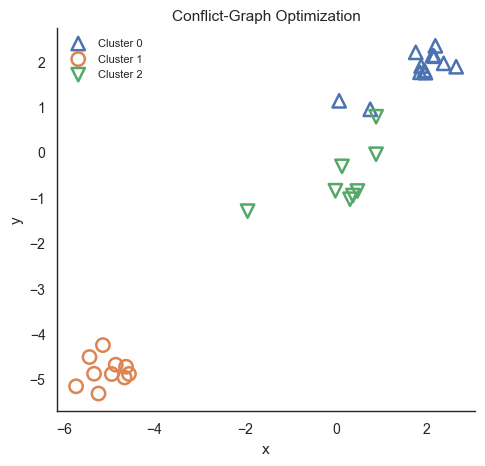

{'pair_accuracy': 0.9172413793103448,
 'balanced_accuracy': 0.9074074074074074,
 'true_positive_rate': 0.8814814814814815,
 'true_negative_rate': 0.9333333333333333,
 'tp': 119,
 'tn': 280,
 'fp': 20,
 'fn': 16,
 'conflicting_edges': 6}

In [25]:
CONFLICT_CLUSTER_COUNT = 3  # Higher permits finer partitions; lower pushes the optimizer toward broader assignments.
CONFLICT_RANDOM_RESTARTS = 10  # Higher searches more random initial clusterings; lower is faster but less robust.
CONFLICT_SWEEPS = 35  # Higher lets reassignment continue longer; lower stops sooner with rougher optima.
CONFLICT_BALANCE_LAMBDA = 0.7  # Higher resists collapse into one cluster; lower focuses more purely on conflict count.
CONFLICT_ESCAPE_MOVES = 2  # Higher helps the search jump away from local minima more aggressively; lower keeps the search greedier.
CONFLICT_SEED = 42  # Higher changes the random initialization of the discrete optimizer.
CONFLICT_CSV_PATH = f"{MAIN_ENV['figure_dir']}/conflict_graph_clusters.csv"  # Change this to archive alternative optimized assignments.
CONFLICT_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/conflict_graph_clusters"  # Change this stem to rename the conflict-graph figure bundle.


def count_conflicting_edges(judgements_df: pd.DataFrame, labels: np.ndarray) -> int:
    conflicts = 0
    for row in judgements_df.itertuples(index=False):
        winner_same = int(labels[int(row.winner_i)] == labels[int(row.winner_j)])
        loser_pairs = [
            (int(row.loser1_i), int(row.loser1_j)),
            (int(row.loser2_i), int(row.loser2_j)),
        ]
        for loser_i, loser_j in loser_pairs:
            loser_same = int(labels[loser_i] == labels[loser_j])
            if loser_same == 1 and winner_same == 0:
                conflicts += 1
    return conflicts


def cluster_balance_penalty(labels: np.ndarray, n_clusters: int) -> float:
    counts = np.bincount(labels.astype(int), minlength=n_clusters).astype(float)
    target = len(labels) / float(n_clusters)
    return float(np.mean((counts - target) ** 2) / max(target, 1.0))


def optimize_meta_graph_clustering(
    judgements_df: pd.DataFrame,
    n_points: int,
    n_clusters: int,
    n_restarts: int,
    n_sweeps: int,
    balance_lambda: float,
    escape_moves: int,
    seed: int,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    best_labels = None
    best_value = np.inf

    def objective(candidate: np.ndarray) -> float:
        return count_conflicting_edges(judgements_df, candidate) + balance_lambda * cluster_balance_penalty(candidate, n_clusters)

    for _ in range(n_restarts):
        labels = rng.integers(0, n_clusters, size=n_points, endpoint=False)
        current_value = objective(labels)
        best_restart_labels = labels.copy()
        best_restart_value = current_value

        for sweep_idx in range(n_sweeps):
            improved = False
            order = np.arange(n_points)
            rng.shuffle(order)
            for point_idx in order:
                current_cluster = labels[point_idx]
                local_best_cluster = current_cluster
                local_best_value = current_value
                for candidate_cluster in range(n_clusters):
                    if candidate_cluster == current_cluster:
                        continue
                    labels[point_idx] = candidate_cluster
                    candidate_value = objective(labels)
                    if candidate_value < local_best_value:
                        local_best_cluster = candidate_cluster
                        local_best_value = candidate_value
                    labels[point_idx] = current_cluster
                if local_best_cluster != current_cluster:
                    labels[point_idx] = local_best_cluster
                    current_value = local_best_value
                    improved = True
                    if current_value < best_restart_value:
                        best_restart_value = current_value
                        best_restart_labels = labels.copy()

            if not improved:
                jump_indices = rng.choice(n_points, size=min(escape_moves, n_points), replace=False)
                for jump_idx in np.atleast_1d(jump_indices):
                    labels[int(jump_idx)] = int(rng.integers(0, n_clusters))
                current_value = objective(labels)
                if current_value < best_restart_value:
                    best_restart_value = current_value
                    best_restart_labels = labels.copy()

        if best_restart_value < best_value:
            best_value = best_restart_value
            best_labels = best_restart_labels.copy()

    return np.asarray(best_labels, dtype=int)


def run_conflict_cell(
    points_csv_path: str | Path,
    judgements_csv_path: str | Path,
    n_clusters: int,
    n_restarts: int,
    n_sweeps: int,
    balance_lambda: float,
    escape_moves: int,
    seed: int,
    csv_path: str | Path,
    figure_stem: str | Path,
) -> dict:
    points_df = pd.read_csv(points_csv_path)
    judgements_df = pd.read_csv(judgements_csv_path)
    inferred = optimize_meta_graph_clustering(
        judgements_df=judgements_df,
        n_points=len(points_df),
        n_clusters=n_clusters,
        n_restarts=n_restarts,
        n_sweeps=n_sweeps,
        balance_lambda=balance_lambda,
        escape_moves=escape_moves,
        seed=seed,
    )
    export_df = points_df.copy()
    export_df["inferred_cluster"] = inferred
    save_dataframe(export_df, csv_path)
    plot_cluster_assignments_from_csv(csv_path, figure_stem, "Conflict-Graph Optimization")
    metrics = pairwise_consistency_metrics(export_df["true_cluster"], export_df["inferred_cluster"])
    metrics["conflicting_edges"] = count_conflicting_edges(judgements_df, inferred)
    logging.info("Conflict graph metrics: %s", metrics)
    return {"clusters_df": export_df, "csv_path": str(csv_path), "metrics": metrics}


MAIN_STATE["conflict_graph"] = run_conflict_cell(
    points_csv_path=MAIN_STATE["dataset"]["csv_path"],
    judgements_csv_path=MAIN_STATE["judgements"]["judgements_csv_path"],
    n_clusters=CONFLICT_CLUSTER_COUNT,
    n_restarts=CONFLICT_RANDOM_RESTARTS,
    n_sweeps=CONFLICT_SWEEPS,
    balance_lambda=CONFLICT_BALANCE_LAMBDA,
    escape_moves=CONFLICT_ESCAPE_MOVES,
    seed=CONFLICT_SEED,
    csv_path=CONFLICT_CSV_PATH,
    figure_stem=CONFLICT_FIGURE_STEM,
)

MAIN_STATE["conflict_graph"]["metrics"]


## Cell 8 – Learn Embedding


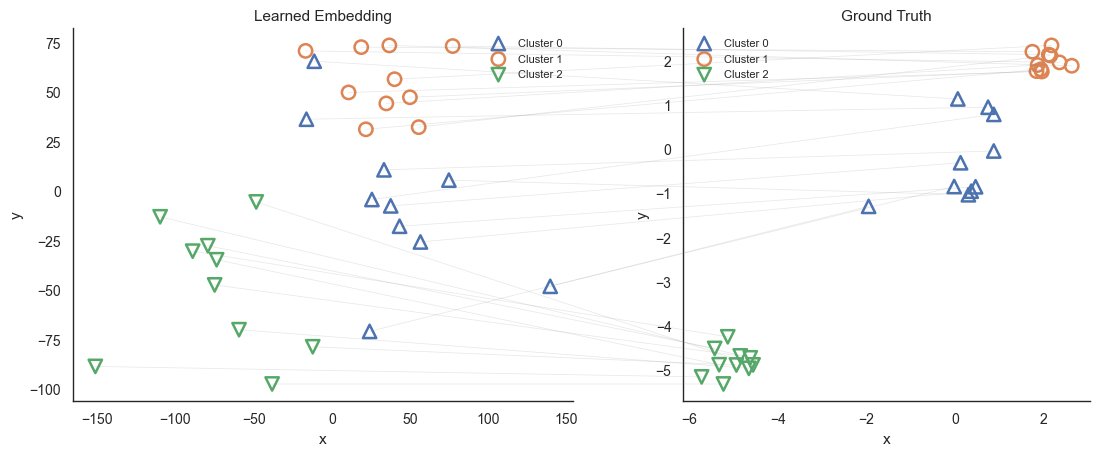

[0.006094174385070801,
 0.006384706497192383,
 0.00625363826751709,
 0.0065332984924316405,
 0.006643972396850586]

In [27]:
EMBEDDING_DIM = 2  # Higher supports richer geometry; lower forces a tighter latent representation.
EMBEDDING_LR = 0.05  # Higher converges faster but can oscillate; lower is steadier but slower.
EMBEDDING_EPOCHS = 5000  # Higher fits the judgement likelihood more closely; lower shortens runtime but may underfit.
EMBEDDING_BATCH_SIZE = 8  # Higher smooths gradients; lower gives noisier updates and more parameter steps.
EMBEDDING_MULTI_STARTS = 10  # Higher explores more random initial embeddings; lower is faster but less robust.
EMBEDDING_SEED = 42  # Higher changes the random starting coordinates of the embedding.
EMBEDDING_CSV_PATH = f"{MAIN_ENV['figure_dir']}/embedding_comparison.csv"  # Change this to archive multiple embedding solutions.
EMBEDDING_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/embedding_comparison"  # Change this stem to rename the embedding figure bundle.


def bradley_terry_log_likelihood(
    embedding_tensor: torch.Tensor,
    winner_pairs: torch.Tensor,
    loser_pairs_1: torch.Tensor,
    loser_pairs_2: torch.Tensor,
) -> torch.Tensor:
    def pair_distance(pair_tensor: torch.Tensor) -> torch.Tensor:
        return torch.norm(embedding_tensor[pair_tensor[:, 0]] - embedding_tensor[pair_tensor[:, 1]], dim=-1)

    d_w = pair_distance(winner_pairs)
    d_l1 = pair_distance(loser_pairs_1)
    d_l2 = pair_distance(loser_pairs_2)
    logits = torch.stack([-d_w, -d_l1, -d_l2], dim=-1)
    return (-d_w - torch.logsumexp(logits, dim=-1)).mean()


def _train_embedding_once(
    points_df: pd.DataFrame,
    judgements_df: pd.DataFrame,
    dim: int,
    lr: float,
    epochs: int,
    batch_size: int,
    seed: int,
    device: str,
    dtype: torch.dtype,
) -> tuple[np.ndarray, list[float], float]:
    seed_everything(seed)
    winner_pairs = torch.tensor(judgements_df[["winner_i", "winner_j"]].to_numpy(dtype=np.int64), dtype=torch.long, device=device)
    loser_pairs_1 = torch.tensor(judgements_df[["loser1_i", "loser1_j"]].to_numpy(dtype=np.int64), dtype=torch.long, device=device)
    loser_pairs_2 = torch.tensor(judgements_df[["loser2_i", "loser2_j"]].to_numpy(dtype=np.int64), dtype=torch.long, device=device)

    embedding = nn.Parameter(torch.randn(len(points_df), dim, dtype=dtype, device=device))
    optimizer = optim.Adam([embedding], lr=lr)
    losses = []
    n_obs = len(judgements_df)

    for _ in range(epochs):
        order = torch.randperm(n_obs, device=device)
        batch_losses = []
        for start in range(0, n_obs, batch_size):
            idx = order[start:start + batch_size]
            optimizer.zero_grad()
            log_like = bradley_terry_log_likelihood(
                embedding,
                winner_pairs[idx],
                loser_pairs_1[idx],
                loser_pairs_2[idx],
            )
            loss = -log_like
            loss.backward()
            optimizer.step()
            batch_losses.append(float(loss.detach().cpu()))
        losses.append(float(np.mean(batch_losses)))

    learned = embedding.detach().cpu().numpy()
    gt_coords = points_df[["x", "y"]].to_numpy(dtype=float)
    centered_gt = gt_coords - gt_coords.mean(axis=0)
    centered_learned = learned - learned.mean(axis=0)
    rotation, _ = orthogonal_procrustes(centered_learned, centered_gt)
    aligned = centered_learned @ rotation
    return aligned, losses, float(losses[-1])


def learn_embedding_from_judgements(
    points_df: pd.DataFrame,
    judgements_df: pd.DataFrame,
    dim: int,
    lr: float,
    epochs: int,
    batch_size: int,
    n_starts: int,
    seed: int,
    device: str,
    dtype: torch.dtype,
    show_progress: bool = False,
) -> tuple[np.ndarray, list[float]]:
    best_embedding = None
    best_losses = None
    best_final_loss = np.inf
    iterator = progress_iter(range(n_starts), enabled=show_progress, desc="Embedding starts", leave=False)
    for start_idx in iterator:
        aligned, losses, final_loss = _train_embedding_once(
            points_df=points_df,
            judgements_df=judgements_df,
            dim=dim,
            lr=lr,
            epochs=epochs,
            batch_size=batch_size,
            seed=seed + 97 * start_idx,
            device=device,
            dtype=dtype,
        )
        if final_loss < best_final_loss:
            best_final_loss = final_loss
            best_embedding = aligned
            best_losses = losses
    return np.asarray(best_embedding), list(best_losses)


def export_embedding_comparison_csv(points_df: pd.DataFrame, learned_embedding: np.ndarray, csv_path: str | Path) -> Path:
    rows = []
    gt_coords = points_df[["x", "y"]].to_numpy(dtype=float)
    for row in points_df.itertuples(index=False):
        learned_x, learned_y = learned_embedding[int(row.point_idx)]
        rows.append(
            {
                "panel": "learned",
                "point_idx": int(row.point_idx),
                "x": float(learned_x),
                "y": float(learned_y),
                "true_cluster": int(row.true_cluster),
            }
        )
        rows.append(
            {
                "panel": "ground_truth",
                "point_idx": int(row.point_idx),
                "x": float(gt_coords[int(row.point_idx), 0]),
                "y": float(gt_coords[int(row.point_idx), 1]),
                "true_cluster": int(row.true_cluster),
            }
        )
    save_dataframe(pd.DataFrame(rows), csv_path)
    return Path(csv_path)


def plot_embedding_comparison_from_csv(
    csv_path: str | Path,
    stem: str | Path,
    markers: tuple[str, ...] = CLUSTER_MARKERS,
    colors: tuple[str, ...] = CLUSTER_COLORS,
) -> tuple[Path, Path]:
    df = pd.read_csv(csv_path)
    learned_df = df[df["panel"] == "learned"].copy().sort_values("point_idx")
    gt_df = df[df["panel"] == "ground_truth"].copy().sort_values("point_idx")
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11.6, 4.7))
    for cluster_id in sorted(df["true_cluster"].unique()):
        mask_left = learned_df["true_cluster"] == cluster_id
        mask_right = gt_df["true_cluster"] == cluster_id
        ax_left.scatter(
            learned_df.loc[mask_left, "x"],
            learned_df.loc[mask_left, "y"],
            facecolors="none",
            edgecolors=cluster_color(int(cluster_id), colors),
            marker=cluster_marker(int(cluster_id), markers),
            linewidths=1.8,
            s=92,
            label=f"Cluster {int(cluster_id)}",
        )
        ax_right.scatter(
            gt_df.loc[mask_right, "x"],
            gt_df.loc[mask_right, "y"],
            facecolors="none",
            edgecolors=cluster_color(int(cluster_id), colors),
            marker=cluster_marker(int(cluster_id), markers),
            linewidths=1.8,
            s=92,
            label=f"Cluster {int(cluster_id)}",
        )

    for left_row, right_row in zip(learned_df.itertuples(index=False), gt_df.itertuples(index=False)):
        fig.add_artist(
            ConnectionPatch(
                xyA=(left_row.x, left_row.y),
                coordsA=ax_left.transData,
                xyB=(right_row.x, right_row.y),
                coordsB=ax_right.transData,
                color="gray",
                alpha=0.18,
                linewidth=0.55,
            )
        )

    ax_left.set_title("Learned Embedding")
    ax_right.set_title("Ground Truth")
    for ax in (ax_left, ax_right):
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend(frameon=False, fontsize=8)
        ax.grid(False)
        sns.despine(ax=ax)
    ax_right.set_aspect("equal", adjustable="box")

    fig.tight_layout()
    paths = save_figure_bundle(fig, stem)
    plt.show()
    plt.close(fig)
    return paths


def run_embedding_cell(
    points_csv_path: str | Path,
    judgements_csv_path: str | Path,
    dim: int,
    lr: float,
    epochs: int,
    batch_size: int,
    n_starts: int,
    seed: int,
    csv_path: str | Path,
    figure_stem: str | Path,
) -> dict:
    points_df = pd.read_csv(points_csv_path)
    judgements_df = pd.read_csv(judgements_csv_path)
    learned_embedding, losses = learn_embedding_from_judgements(
        points_df=points_df,
        judgements_df=judgements_df,
        dim=dim,
        lr=lr,
        epochs=epochs,
        batch_size=batch_size,
        n_starts=n_starts,
        seed=seed,
        device=MAIN_ENV["device"],
        dtype=MAIN_ENV["dtype"],
        show_progress=True,
    )
    export_embedding_comparison_csv(points_df, learned_embedding, csv_path)
    plot_embedding_comparison_from_csv(csv_path, figure_stem)
    embedding_df = pd.read_csv(csv_path)
    logging.info("Embedding cell complete. Final loss %.4f", losses[-1])
    return {"embedding_df": embedding_df, "csv_path": str(csv_path), "losses": losses}


MAIN_STATE["embedding"] = run_embedding_cell(
    points_csv_path=MAIN_STATE["dataset"]["csv_path"],
    judgements_csv_path=MAIN_STATE["judgements"]["judgements_csv_path"],
    dim=EMBEDDING_DIM,
    lr=EMBEDDING_LR,
    epochs=EMBEDDING_EPOCHS,
    batch_size=EMBEDDING_BATCH_SIZE,
    n_starts=EMBEDDING_MULTI_STARTS,
    seed=EMBEDDING_SEED,
    csv_path=EMBEDDING_CSV_PATH,
    figure_stem=EMBEDDING_FIGURE_STEM,
)

MAIN_STATE["embedding"]["losses"][-5:]


## Cell 9 – K-means Clustering on the Embedding


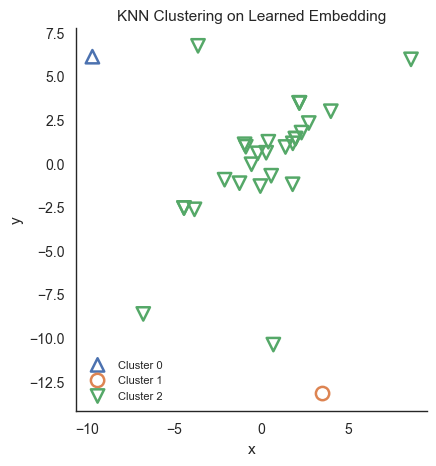

{'pair_accuracy': 0.3632183908045977,
 'balanced_accuracy': 0.5037037037037038,
 'true_positive_rate': 0.8740740740740741,
 'true_negative_rate': 0.13333333333333333,
 'tp': 118,
 'tn': 40,
 'fp': 260,
 'fn': 17}

In [10]:
KMEANS_CLUSTER_COUNT = 3  # Higher asks for finer embedding clusters; lower merges broader regions.
KMEANS_N_INIT = 10  # Higher explores more random centroid initializations; lower is faster but less stable.
KMEANS_MAX_ITER = 100  # Higher lets Lloyd updates settle more fully; lower stops earlier.
KMEANS_CSV_PATH = f"{MAIN_ENV['figure_dir']}/kmeans_embedding_clusters.csv"  # Change this to archive alternative k-means outputs.
KMEANS_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/kmeans_embedding_clusters"  # Change this stem to rename the k-means figure bundle.


def cluster_kmeans_embedding(
    embedding_df: pd.DataFrame,
    n_clusters: int,
    n_init: int,
    max_iter: int,
    seed: int,
) -> np.ndarray:
    embedding_xy = embedding_df[["x", "y"]].to_numpy(dtype=float)
    return run_kmeans(embedding_xy, n_clusters=n_clusters, n_init=n_init, max_iter=max_iter, seed=seed)


def run_kmeans_cell(
    points_csv_path: str | Path,
    embedding_csv_path: str | Path,
    n_clusters: int,
    n_init: int,
    max_iter: int,
    seed: int,
    csv_path: str | Path,
    figure_stem: str | Path,
) -> dict:
    points_df = pd.read_csv(points_csv_path)
    embedding_df = pd.read_csv(embedding_csv_path)
    learned_df = embedding_df[embedding_df["panel"] == "learned"].copy().sort_values("point_idx").reset_index(drop=True)
    inferred = cluster_kmeans_embedding(learned_df, n_clusters, n_init, max_iter, seed)
    export_df = learned_df[["point_idx", "x", "y"]].copy()
    export_df["true_cluster"] = points_df.sort_values("point_idx")["true_cluster"].to_numpy(dtype=int)
    export_df["inferred_cluster"] = inferred
    save_dataframe(export_df, csv_path)
    plot_cluster_assignments_from_csv(csv_path, figure_stem, "K-means Clustering on Learned Embedding")
    metrics = pairwise_consistency_metrics(export_df["true_cluster"], export_df["inferred_cluster"])
    logging.info("K-means embedding metrics: %s", metrics)
    return {"clusters_df": export_df, "csv_path": str(csv_path), "metrics": metrics}


MAIN_STATE["kmeans_embedding"] = run_kmeans_cell(
    points_csv_path=MAIN_STATE["dataset"]["csv_path"],
    embedding_csv_path=MAIN_STATE["embedding"]["csv_path"],
    n_clusters=KMEANS_CLUSTER_COUNT,
    n_init=KMEANS_N_INIT,
    max_iter=KMEANS_MAX_ITER,
    seed=SETUP_SEED,
    csv_path=KMEANS_CSV_PATH,
    figure_stem=KMEANS_FIGURE_STEM,
)

MAIN_STATE["kmeans_embedding"]["metrics"]


## Cell 10 – Comparison of All Methods


In [11]:
EVAL_RUNS = 20  # Higher gives smoother confidence intervals; lower makes the benchmark finish sooner.
EVAL_MIN_CLUSTERS = 2  # Lower widens the easy end of the benchmark; higher removes the simplest cases.
EVAL_MAX_CLUSTERS = 5  # Higher broadens task variability; lower narrows the family of benchmark problems.
EVAL_POINTS = 50  # Higher increases difficulty and runtime; lower makes each benchmark run smaller.
EVAL_QUERIES = 1000  # Higher yields more evidence per run; lower stresses the methods under stronger scarcity.
EVAL_PREFIX_SIZES = list(range(100, 1001, 100))  # Finer steps draw denser curves; coarser steps reduce benchmark cost.
EVAL_MAXCUT_RESTARTS = 8  # Higher stabilizes the max-cut baseline; lower keeps the benchmark lighter.
EVAL_MAXCUT_MAX_ITER = 80  # Higher lets the local max-cut search settle more; lower shortens each evaluation.
EVAL_MAXCUT_SIZE_REGULARIZATION = 0.55  # Higher pushes evaluation max-cut toward balanced clusters; lower lets the cut objective dominate.
EVAL_CONFLICT_RESTARTS = 10  # Higher explores more random starts for the conflict optimizer; lower is faster.
EVAL_CONFLICT_SWEEPS = 15  # Higher improves discrete refinement; lower stops sooner.
EVAL_CONFLICT_BALANCE_LAMBDA = 0.9  # Higher resists collapsed clusterings; lower focuses more directly on conflict minimization.
EVAL_CONFLICT_ESCAPE_MOVES = 2  # Higher increases the strength of local-minima escape moves; lower keeps the search greedier.
EVAL_EMBED_EPOCHS = 80  # Higher improves learned embeddings; lower keeps repeated evaluation practical.
EVAL_EMBED_BATCH_SIZE = 64  # Higher smooths gradient estimates; lower increases update frequency.
EVAL_EMBED_MULTI_STARTS = 3  # Higher makes the benchmark embedding stage more robust; lower keeps runtime manageable.
EVAL_KMEANS_N_INIT = 8  # Higher stabilizes the k-means post-processing; lower is faster.
EVAL_KMEANS_MAX_ITER = 60  # Higher gives k-means more room to settle; lower shortens each benchmark call.
EVAL_RESULTS_CSV_PATH = f"{MAIN_ENV['figure_dir']}/evaluation_results.csv"  # Change this to archive benchmark results elsewhere.
EVAL_FIGURE_STEM = f"{MAIN_ENV['figure_dir']}/evaluation_balanced_accuracy"  # Change this stem to rename the summary figure bundle.


def allocate_cluster_sizes(n_points: int, n_clusters: int) -> list[int]:
    base = n_points // n_clusters
    sizes = [base] * n_clusters
    for idx in range(n_points - base * n_clusters):
        sizes[idx] += 1
    return sizes


def sample_cluster_params_for_evaluation(n_clusters: int, rng: np.random.Generator) -> list[dict]:
    angles = np.linspace(0.0, 2.0 * np.pi, num=n_clusters, endpoint=False)
    radius = rng.uniform(2.0, 6.0)
    specs = []
    for cluster_id, angle in enumerate(angles):
        specs.append(
            {
                "mean_x": float(radius * np.cos(angle) + rng.normal(scale=0.5)),
                "mean_y": float(radius * np.sin(angle) + rng.normal(scale=0.5)),
                "std": float(rng.uniform(0.25, 0.9)),
                "label": cluster_id,
            }
        )
    return specs


def generate_evaluation_dataset(n_points: int, n_clusters: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    cluster_specs = sample_cluster_params_for_evaluation(n_clusters, rng)
    cluster_sizes = allocate_cluster_sizes(n_points, n_clusters)
    rows = []
    point_idx = 0
    for spec, cluster_size in zip(cluster_specs, cluster_sizes):
        mean = np.array([spec["mean_x"], spec["mean_y"]], dtype=float)
        samples = rng.normal(loc=mean, scale=float(spec["std"]), size=(cluster_size, 2))
        for x_coord, y_coord in samples:
            rows.append(
                {
                    "point_idx": point_idx,
                    "x": float(x_coord),
                    "y": float(y_coord),
                    "true_cluster": int(spec["label"]),
                }
            )
            point_idx += 1
    return pd.DataFrame(rows)


def evaluate_single_method(
    method_name: str,
    points_df: pd.DataFrame,
    judgements_df: pd.DataFrame,
    n_clusters: int,
    seed: int,
) -> np.ndarray:
    if method_name == "maxcut":
        predicted_labels, _ = infer_maxcut_labels_from_judgements(
            judgements_df=judgements_df,
            n_points=len(points_df),
            n_clusters=n_clusters,
            n_restarts=EVAL_MAXCUT_RESTARTS,
            max_iter=EVAL_MAXCUT_MAX_ITER,
            size_regularization=EVAL_MAXCUT_SIZE_REGULARIZATION,
            seed=seed,
        )
        return predicted_labels
    if method_name == "mincut":
        predicted_labels, _ = infer_mincut_labels_from_judgements(
            judgements_df=judgements_df,
            n_points=len(points_df),
            n_clusters=n_clusters,
        )
        return predicted_labels
    if method_name == "conflict_graph":
        return optimize_meta_graph_clustering(
            judgements_df=judgements_df,
            n_points=len(points_df),
            n_clusters=n_clusters,
            n_restarts=EVAL_CONFLICT_RESTARTS,
            n_sweeps=EVAL_CONFLICT_SWEEPS,
            balance_lambda=EVAL_CONFLICT_BALANCE_LAMBDA,
            escape_moves=EVAL_CONFLICT_ESCAPE_MOVES,
            seed=seed,
        )
    if method_name == "kmeans_embedding":
        learned_embedding, _ = learn_embedding_from_judgements(
            points_df=points_df,
            judgements_df=judgements_df,
            dim=2,
            lr=EMBEDDING_LR,
            epochs=EVAL_EMBED_EPOCHS,
            batch_size=EVAL_EMBED_BATCH_SIZE,
            n_starts=EVAL_EMBED_MULTI_STARTS,
            seed=seed,
            device=MAIN_ENV["device"],
            dtype=MAIN_ENV["dtype"],
            show_progress=False,
        )
        return run_kmeans(
            learned_embedding,
            n_clusters=n_clusters,
            n_init=EVAL_KMEANS_N_INIT,
            max_iter=EVAL_KMEANS_MAX_ITER,
            seed=seed,
        )
    raise ValueError(f"Unknown method: {method_name}")


def run_evaluation_benchmark(
    n_runs: int,
    min_clusters: int,
    max_clusters: int,
    n_points: int,
    n_queries: int,
    prefix_sizes: list[int],
    csv_path: str | Path,
    seed: int,
    show_progress: bool = True,
) -> pd.DataFrame:
    methods = ["mincut", "maxcut", "conflict_graph", "kmeans_embedding"]
    rows = []
    run_iterator = progress_iter(range(n_runs), enabled=show_progress, desc="Evaluation runs")
    for run_id in run_iterator:
        run_seed = seed + 1000 * run_id
        rng = np.random.default_rng(run_seed)
        n_clusters = int(rng.integers(min_clusters, max_clusters + 1))
        points_df = generate_evaluation_dataset(n_points, n_clusters, run_seed)
        judgements_df = generate_triplet_judgements(
            points_df=points_df,
            n_judgements=n_queries,
            temperature=1.0,
            seed=run_seed + 1,
            show_progress=False,
        )
        for prefix_size in prefix_sizes:
            subset = judgements_df.head(prefix_size).reset_index(drop=True)
            for method_name in methods:
                predicted_labels = evaluate_single_method(
                    method_name=method_name,
                    points_df=points_df,
                    judgements_df=subset,
                    n_clusters=n_clusters,
                    seed=run_seed + prefix_size,
                )
                metrics = pairwise_consistency_metrics(points_df["true_cluster"], predicted_labels)
                rows.append(
                    {
                        "run_id": run_id,
                        "n_clusters": n_clusters,
                        "n_samples": prefix_size,
                        "method": method_name,
                        "pair_accuracy": metrics["pair_accuracy"],
                        "balanced_accuracy": metrics["balanced_accuracy"],
                        "true_positive_rate": metrics["true_positive_rate"],
                        "true_negative_rate": metrics["true_negative_rate"],
                    }
                )
    results_df = pd.DataFrame(rows)
    save_dataframe(results_df, csv_path)
    return results_df


def plot_evaluation_from_csv(csv_path: str | Path, stem: str | Path) -> tuple[Path, Path]:
    df = pd.read_csv(csv_path)
    fig, ax = plt.subplots(figsize=(8.4, 5.0))
    sns.lineplot(
        data=df,
        x="n_samples",
        y="balanced_accuracy",
        hue="method",
        style="method",
        estimator="mean",
        errorbar=("ci", 95),
        n_boot=300,
        marker="o",
        ax=ax,
    )
    ax.set_title("Balanced Accuracy vs. Number of Queried Triplets")
    ax.set_xlabel("Number of judged triplets used")
    ax.set_ylabel("Balanced accuracy")
    ax.legend(frameon=False, title="Method")
    finalize_axes(ax, equal_aspect=False)
    fig.tight_layout()
    paths = save_figure_bundle(fig, stem)
    plt.show()
    plt.close(fig)
    return paths


def run_evaluation_cell(
    n_runs: int,
    min_clusters: int,
    max_clusters: int,
    n_points: int,
    n_queries: int,
    prefix_sizes: list[int],
    csv_path: str | Path,
    figure_stem: str | Path,
    seed: int,
) -> dict:
    results_df = run_evaluation_benchmark(
        n_runs=n_runs,
        min_clusters=min_clusters,
        max_clusters=max_clusters,
        n_points=n_points,
        n_queries=n_queries,
        prefix_sizes=prefix_sizes,
        csv_path=csv_path,
        seed=seed,
        show_progress=True,
    )
    plot_evaluation_from_csv(csv_path, figure_stem)
    summary_df = (
        results_df.groupby(["method", "n_samples"], as_index=False)
        .agg(
            balanced_accuracy_mean=("balanced_accuracy", "mean"),
            pair_accuracy_mean=("pair_accuracy", "mean"),
        )
    )
    logging.info("Evaluation cell complete with %d benchmark rows", len(results_df))
    return {"results_df": results_df, "summary_df": summary_df, "csv_path": str(csv_path)}


MAIN_STATE["evaluation"] = run_evaluation_cell(
    n_runs=EVAL_RUNS,
    min_clusters=EVAL_MIN_CLUSTERS,
    max_clusters=EVAL_MAX_CLUSTERS,
    n_points=EVAL_POINTS,
    n_queries=EVAL_QUERIES,
    prefix_sizes=EVAL_PREFIX_SIZES,
    csv_path=EVAL_RESULTS_CSV_PATH,
    figure_stem=EVAL_FIGURE_STEM,
    seed=SETUP_SEED,
)

MAIN_STATE["evaluation"]["summary_df"].head(12)


KeyboardInterrupt: 